# Capstone Assignment Part B: Individual Work
## Brahmdev Singh (25236568)
**Equities:** XEL VRSK MRSH AVGO CMG STT PKG STE DOC COP  |  **Period:** 2015-12-31 to 2025-12-31  |  **Risk-free:** 4% p.a.

## Setup: Imports, Settings & Data Download

In [26]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize
import statsmodels.api as sm
import yfinance as yf

TICKERS = ["XEL", "VRSK", "MRSH", "AVGO", "CMG", "STT", "PKG", "STE", "DOC", "COP"]
MARKET  = "^GSPC"
START   = "2015-12-31"
END     = "2025-12-31"
RF      = 0.04
DAYS    = 252
RF_D    = RF / DAYS

COMPANY = {
    "XEL":  ("Xcel Energy",           "Utilities",        "Electric & gas utility; ~4M customers across MN, CO, TX, NM; major wind energy operator."),
    "VRSK": ("Verisk Analytics",       "Industrials",      "Data analytics & risk assessment for insurance, energy, and financial markets; subscription-based moat."),
    "MRSH": ("Marsh & McLennan",       "Financials",       "World's largest insurance broker; owns Mercer, Oliver Wyman; recurring fee-based revenues."),
    "AVGO": ("Broadcom Inc.",          "Technology",       "Semiconductor & infrastructure software; AI/data-centre chips, VMware cloud software; M&A-driven growth."),
    "CMG":  ("Chipotle Mexican Grill", "Consumer Discret.","Fast-casual Mexican chain; 3,500+ US locations; digital ordering strength; no-franchise model."),
    "STT":  ("State Street Corp.",     "Financials",       "Custody banking giant; $44T AUC; issues SPDR ETFs; revenue tied to market levels."),
    "PKG":  ("Packaging Corp.",        "Materials",        "3rd-largest US containerboard & corrugated packaging producer; e-commerce beneficiary."),
    "STE":  ("STERIS plc",             "Health Care",      "Infection-prevention & sterilisation products/services for hospitals and pharma; consumable-led."),
    "DOC":  ("Healthpeak Properties",  "Real Estate",      "Healthcare REIT; ~480 outpatient medical buildings and life-science campuses across the US."),
    "COP":  ("ConocoPhillips",         "Energy",           "World's largest independent E&P; diversified production; disciplined capital-return programme."),
}

COLORS = plt.cm.tab10(np.linspace(0, 1, len(TICKERS)))

print("Downloading price data...")
all_tix = TICKERS + [MARKET]
# Pull adjusted close prices for the stocks and market index
raw = yf.download(all_tix, start=START, end=END, auto_adjust=True, progress=False)["Close"]
raw = raw[all_tix]
raw.dropna(how="all", inplace=True)
raw.ffill(inplace=True)

log_ret = np.log(raw / raw.shift(1)).dropna()
eq_ret  = log_ret[TICKERS]
mkt_ret = log_ret[MARKET]
print(f"Data: {log_ret.index[0].date()} to {log_ret.index[-1].date()}, {len(log_ret)} trading days\n")

Data: 2016-01-04 to 2025-12-30, 2513 trading days



## Question 1: Maximize Sharpe-Ratio Portfolio

In [27]:
print("=" * 60)
print("QUESTION 1: SHARPE-RATIO PORTFOLIO")
print("=" * 60)
# Annualise the main summary statistics
ann_mean  = eq_ret.mean() * DAYS
ann_std   = eq_ret.std(ddof=1) * np.sqrt(DAYS)
ann_sr    = (ann_mean - RF) / ann_std
skew      = eq_ret.skew()
kurt      = eq_ret.kurt()
cum_ret   = eq_ret.sum()

print("\nSummary Statistics (Annualised):")
print(f"{'Ticker':<8} {'Ann.Return':>12} {'Ann.Vol':>10} {'Sharpe':>10} {'Skewness':>10} {'Ex.Kurt':>10} {'Total LogRet':>14}")
print("-" * 76)
for t in TICKERS:
    print(f"{t:<8} {ann_mean[t]:>11.2%} {ann_std[t]:>10.2%} {ann_sr[t]:>10.3f} {skew[t]:>10.3f} {kurt[t]:>10.3f} {cum_ret[t]:>13.2%}")

QUESTION 1: SHARPE-RATIO PORTFOLIO

Summary Statistics (Annualised):
Ticker     Ann.Return    Ann.Vol     Sharpe   Skewness    Ex.Kurt   Total LogRet
----------------------------------------------------------------------------
XEL           10.37%     21.60%      0.295     -0.734     13.030       103.42%
VRSK          11.19%     23.15%      0.311     -0.729     11.745       111.63%
MRSH          13.91%     20.37%      0.486     -0.611     14.286       138.68%
AVGO          34.61%     38.88%      0.787     -0.192     11.330       345.09%
CMG           13.54%     35.61%      0.268      0.068     12.673       135.05%
STT            9.58%     33.24%      0.168     -0.444     11.664        95.51%
PKG           14.95%     27.59%      0.397     -0.209      8.304       149.11%
STE           13.31%     24.92%      0.373     -0.383      7.896       132.69%
DOC           -2.38%     29.89%     -0.213     -1.469     23.586       -23.72%
COP           10.10%     38.72%      0.158     -0.563     14.7

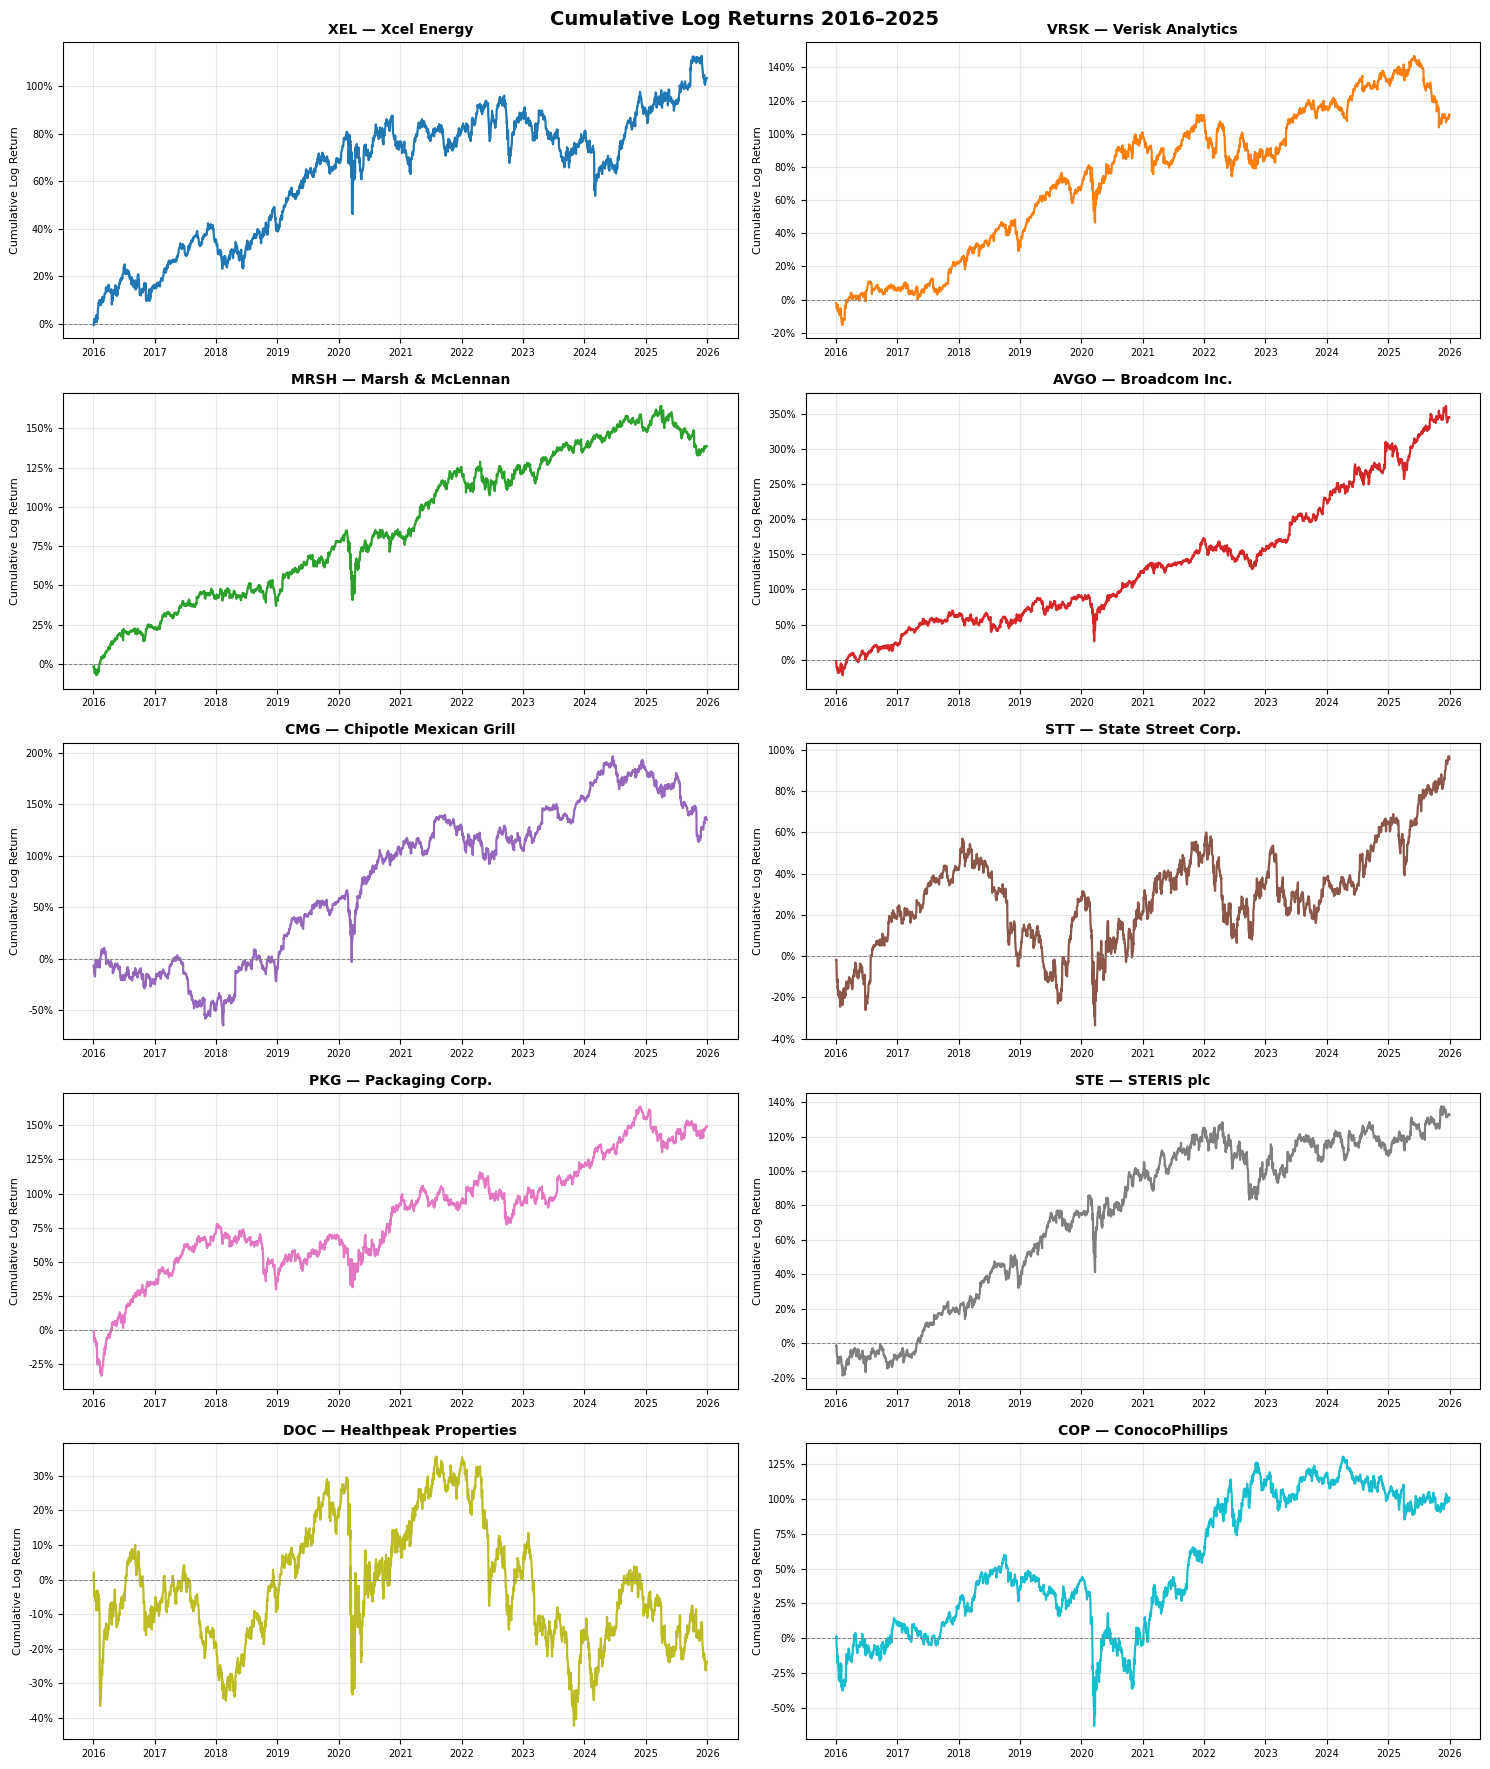


Saved: q1_fig1_cumulative_returns.png

Tangency Portfolio:
  Expected Return : 24.3636%
  Volatility      : 24.5277%
  Sharpe Ratio    : 0.8302

Portfolio Weights:
  XEL     12.7804%
  MRSH    25.6438%
  AVGO    52.2310%
  PKG     9.3448%
  Risk-Free Asset: 0.00%  (full allocation to tangency)


In [28]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()
for i, t in enumerate(TICKERS):
    ax = axes[i]
    cs = eq_ret[t].cumsum()
    ax.plot(cs.index, cs.values, color=COLORS[i], linewidth=1.6)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title(f"{t} — {COMPANY[t][0]}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Cumulative Log Return", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("Cumulative Log Returns 2016–2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nSaved: q1_fig1_cumulative_returns.png")

mu    = ann_mean.values
Sigma = eq_ret.cov().values * DAYS
N     = len(TICKERS)
# Objective function: minimise negative Sharpe ratio
def neg_sharpe(w):
    r = w @ mu
    v = np.sqrt(w @ Sigma @ w)
    return -(r - RF) / v

cons   = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * N
rng    = np.random.default_rng(42)
best_sr_val, best_w = -np.inf, None
# Try different starting weights so the optimiser is less sensitive to the initial guess
for _ in range(500):
    w0  = rng.dirichlet(np.ones(N))
    res = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds,
                   constraints=cons, options={"ftol": 1e-12, "maxiter": 1000})
    if res.success and (-res.fun) > best_sr_val:
        best_sr_val = -res.fun
        best_w = res.x

w_tan = best_w.copy()

w_tan[w_tan < 1e-6] = 0
w_tan /= w_tan.sum()
# Remove tiny numerical weights before reporting the final portfolio
mu_tan  = w_tan @ mu
vol_tan = np.sqrt(w_tan @ Sigma @ w_tan)
sr_tan  = (mu_tan - RF) / vol_tan

print(f"\nTangency Portfolio:")
print(f"  Expected Return : {mu_tan:.4%}")
print(f"  Volatility      : {vol_tan:.4%}")
print(f"  Sharpe Ratio    : {sr_tan:.4f}")
print(f"\nPortfolio Weights:")
for t, w in zip(TICKERS, w_tan):
    if w > 0.0001:
        print(f"  {t:<6}  {w:.4%}")
print(f"  Risk-Free Asset: 0.00%  (full allocation to tangency)")

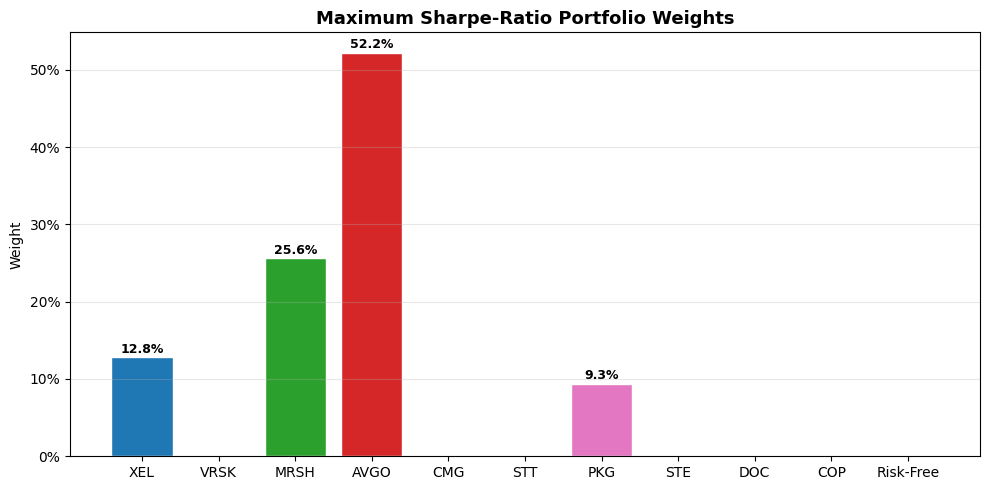

Saved: q1_fig2_portfolio_weights.png

Simulating efficient frontier...


In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
bar_w = list(w_tan) + [0.0]
bar_t = TICKERS + ["Risk-Free"]
bar_c = [COLORS[i] for i in range(N)] + ["silver"]
bars  = ax.bar(bar_t, bar_w, color=bar_c, edgecolor="white")
for bar, w in zip(bars, bar_w):
    if w > 0.001:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{w:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Weight")
ax.set_title("Maximum Sharpe-Ratio Portfolio Weights", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q1_fig2_portfolio_weights.png")

print("\nSimulating efficient frontier...")
N_SIM = 50000
sim_r = np.empty(N_SIM)
sim_v = np.empty(N_SIM)
rng2  = np.random.default_rng(0)
for i in range(N_SIM):
    w = rng2.dirichlet(np.ones(N))
    sim_r[i] = w @ mu
    sim_v[i] = np.sqrt(w @ Sigma @ w)
sim_sr = (sim_r - RF) / sim_v

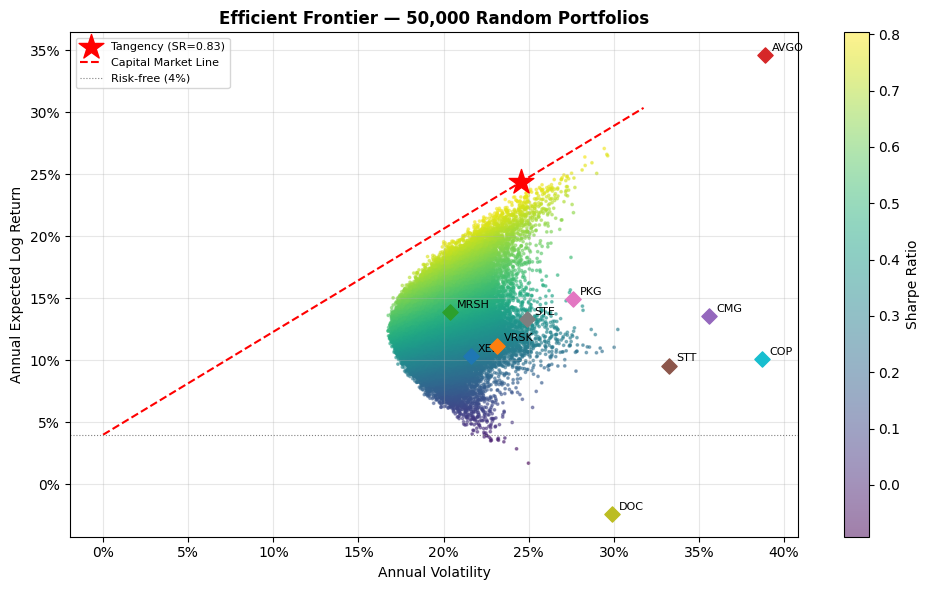

Saved: q1_fig3_efficient_frontier.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sim_v, sim_r, c=sim_sr, cmap="viridis", s=3, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")
for j, t in enumerate(TICKERS):
    ax.scatter(ann_std[t], ann_mean[t], marker="D", s=60, color=COLORS[j], zorder=5)
    ax.annotate(t, (ann_std[t], ann_mean[t]), textcoords="offset points", xytext=(5, 3), fontsize=8)
ax.scatter(vol_tan, mu_tan, marker="*", s=350, color="red", zorder=6, label=f"Tangency (SR={sr_tan:.2f})")
vols_cml  = np.linspace(0, sim_v.max() * 1.05, 200)
ax.plot(vols_cml, RF + sr_tan * vols_cml, "r--", linewidth=1.5, label="Capital Market Line")
ax.axhline(RF, color="gray", linewidth=0.8, linestyle=":", label=f"Risk-free (4%)")
ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Annual Expected Log Return")
ax.set_title("Efficient Frontier — 50,000 Random Portfolios", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q1_fig3_efficient_frontier.png")

corr = eq_ret.corr()

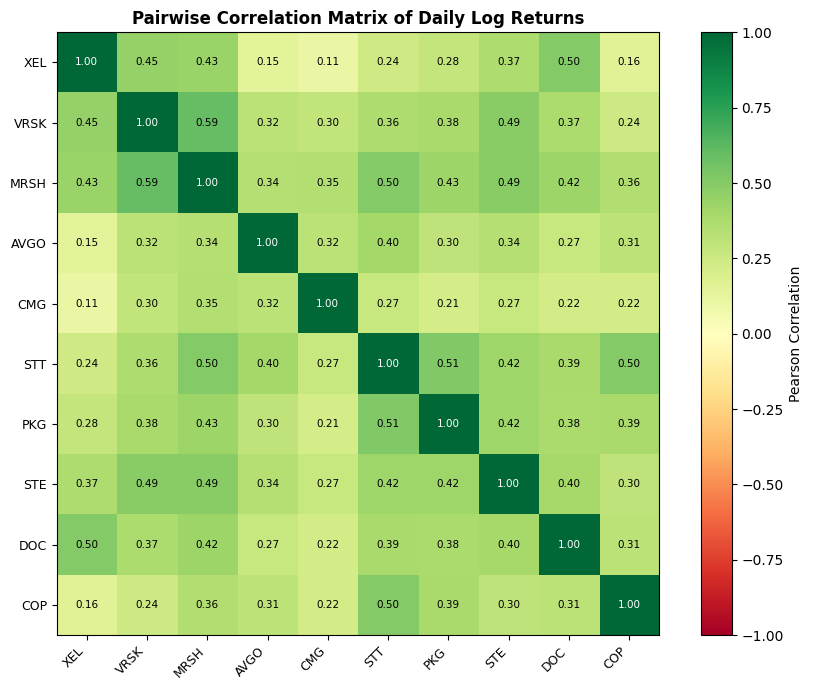

Saved: q1_fig4_correlation_heatmap.png


In [31]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(TICKERS, fontsize=9)
for i in range(N):
    for j in range(N):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="black" if abs(corr.values[i,j]) < 0.7 else "white")
ax.set_title("Pairwise Correlation Matrix of Daily Log Returns", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q1_fig4_correlation_heatmap.png")

port_ret = (eq_ret * w_tan).sum(axis=1)
eq_w     = np.ones(N) / N
eq_port  = (eq_ret * eq_w).sum(axis=1)
best_idx = int(np.argmax((ann_mean.values - RF) / ann_std.values))
best_t   = TICKERS[best_idx]

roll_tan = port_ret.rolling(63).std() * np.sqrt(DAYS)
roll_eq  = eq_port.rolling(63).std()  * np.sqrt(DAYS)
roll_bs  = eq_ret[best_t].rolling(63).std() * np.sqrt(DAYS)

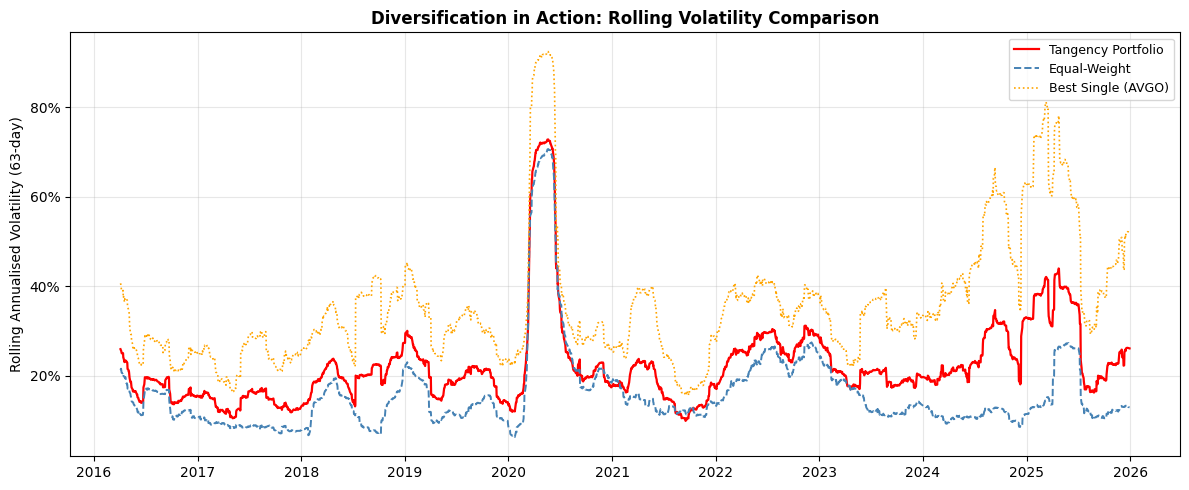

Saved: q1_fig5_diversification.png

Diversification Comparison:
  Portfolio                        Return   Volatility     Sharpe
  ------------------------------------------------------------
  Best single (AVGO)               34.61%       38.88%     0.7872
  Equal-weight                     12.92%       18.78%     0.4749
  Max-Sharpe Tangency              24.36%       24.53%     0.8302


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(roll_tan.index, roll_tan, color="red",       linewidth=1.6, label="Tangency Portfolio")
ax.plot(roll_eq.index,  roll_eq,  color="steelblue", linewidth=1.4, linestyle="--", label="Equal-Weight")
ax.plot(roll_bs.index,  roll_bs,  color="orange",    linewidth=1.2, linestyle=":",  label=f"Best Single ({best_t})")
ax.set_ylabel("Rolling Annualised Volatility (63-day)")
ax.set_title("Diversification in Action: Rolling Volatility Comparison", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q1_fig5_diversification.png")

mu_eq   = eq_w @ mu
vol_eq  = np.sqrt(eq_w @ Sigma @ eq_w)
sr_eq   = (mu_eq - RF) / vol_eq
mu_bs   = ann_mean.iloc[best_idx]
vol_bs  = ann_std.iloc[best_idx]
sr_bs   = (mu_bs - RF) / vol_bs
print(f"\nDiversification Comparison:")
print(f"  {'Portfolio':<28} {'Return':>10} {'Volatility':>12} {'Sharpe':>10}")
print(f"  {'-'*60}")
print(f"  {'Best single (' + best_t + ')':<28} {mu_bs:>10.2%} {vol_bs:>12.2%} {sr_bs:>10.4f}")
print(f"  {'Equal-weight':<28} {mu_eq:>10.2%} {vol_eq:>12.2%} {sr_eq:>10.4f}")
print(f"  {'Max-Sharpe Tangency':<28} {mu_tan:>10.2%} {vol_tan:>12.2%} {sr_tan:>10.4f}")

## Question 2: CAPM Model

In [33]:
print("\n" + "=" * 60)
print("QUESTION 2: CAPM MODEL")
print("=" * 60)

port_excess = port_ret  - RF_D
mkt_excess  = mkt_ret   - RF_D

X     = sm.add_constant(mkt_excess.values)
y     = port_excess.values
model = sm.OLS(y, X).fit()
alpha = model.params[0]
beta  = model.params[1]
r2    = model.rsquared
resid = model.resid

alpha_ann = alpha * DAYS
se_alpha  = model.bse[0]
se_beta   = model.bse[1]
t_alpha   = model.tvalues[0]
t_beta    = model.tvalues[1]
p_alpha   = model.pvalues[0]
p_beta    = model.pvalues[1]

print(f"\nCAPM Regression Results:")
print(f"  Alpha (daily)      : {alpha:.8f}")
print(f"  Alpha (annualised) : {alpha_ann:.4%}")
print(f"  Beta               : {beta:.6f}")
print(f"  R-squared          : {r2:.6f}")
print(f"  t(alpha)           : {t_alpha:.4f}   p = {p_alpha:.4f}")
print(f"  t(beta)            : {t_beta:.4f}   p = {p_beta:.6f}")


QUESTION 2: CAPM MODEL

CAPM Regression Results:
  Alpha (daily)      : 0.00045454
  Alpha (annualised) : 11.4544%
  Beta               : 1.087169
  R-squared          : 0.649565
  t(alpha)           : 2.4897   p = 0.0128
  t(beta)            : 68.2230   p = 0.000000


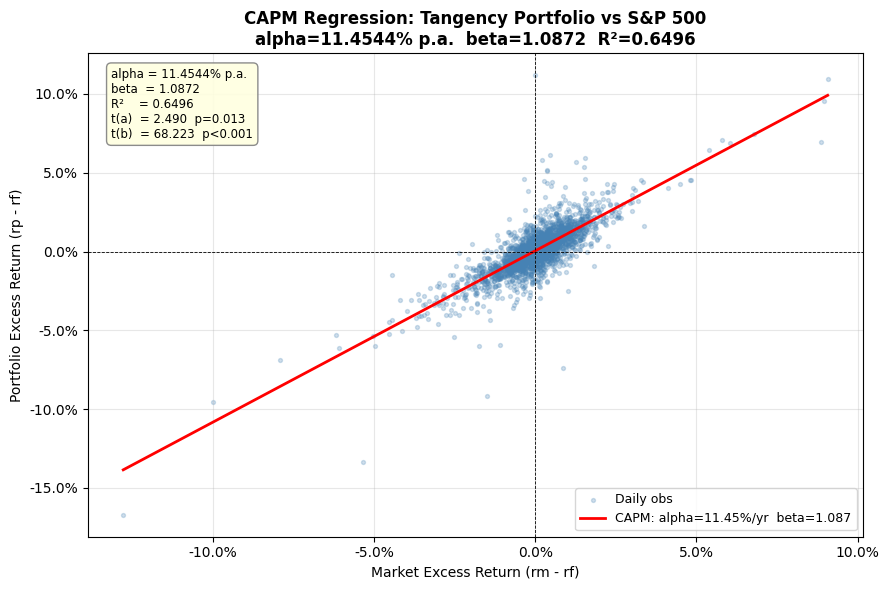


Saved: q2_fig1_capm_scatter.png


In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(mkt_excess.values, port_excess.values, alpha=0.25, s=8, color="steelblue", label="Daily obs")
x_line = np.linspace(mkt_excess.min(), mkt_excess.max(), 200)
ax.plot(x_line, alpha + beta * x_line, color="red", linewidth=2,
        label=f"CAPM: alpha={alpha_ann:.2%}/yr  beta={beta:.3f}")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("Market Excess Return (rm - rf)")
ax.set_ylabel("Portfolio Excess Return (rp - rf)")
ax.set_title(f"CAPM Regression: Tangency Portfolio vs S&P 500\nalpha={alpha_ann:.4%} p.a.  beta={beta:.4f}  R²={r2:.4f}",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
stats_txt = (f"alpha = {alpha_ann:.4%} p.a.\nbeta  = {beta:.4f}\nR²    = {r2:.4f}\n"
             f"t(a)  = {t_alpha:.3f}  p={p_alpha:.3f}\nt(b)  = {t_beta:.3f}  p<0.001")
ax.text(0.03, 0.97, stats_txt, transform=ax.transAxes, fontsize=8.5, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", edgecolor="gray", alpha=0.9))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nSaved: q2_fig1_capm_scatter.png")

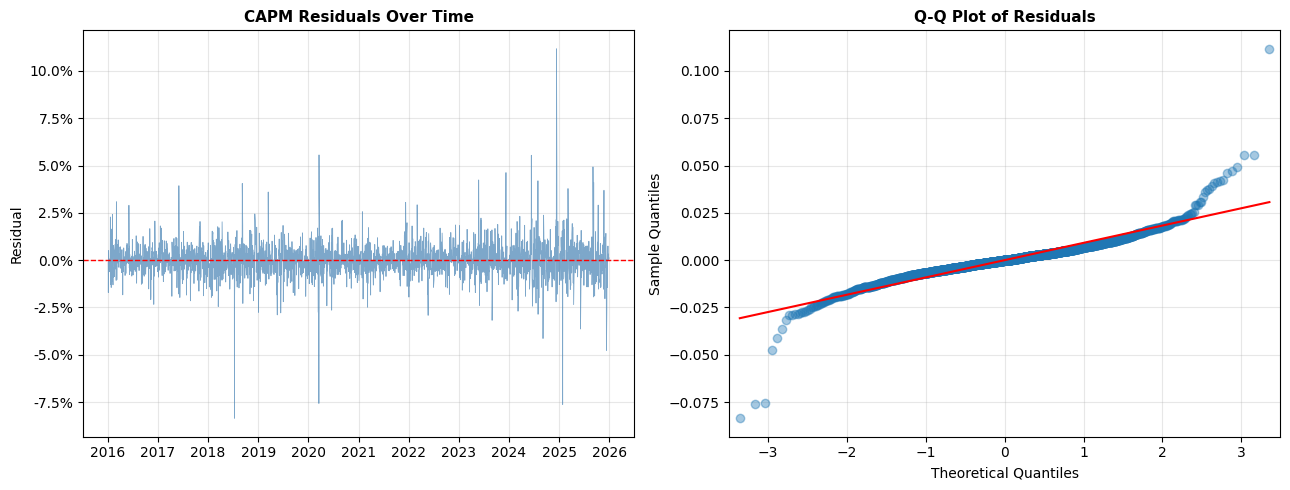

Saved: q2_fig2_residuals.png

Variance Decomposition:
  Total variance      : 0.00023873
  Systematic variance : 0.00015507   (64.96%)
  Idiosyncratic var   : 0.00008366   (35.04%)
  Ann. Total Vol      : 24.5277%
  Ann. Systematic Vol : 19.7683%
  Ann. Idio Vol       : 14.5198%


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(port_ret.index, resid, color="steelblue", linewidth=0.6, alpha=0.7)
axes[0].axhline(0, color="red", linewidth=1, linestyle="--")
axes[0].set_title("CAPM Residuals Over Time", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Residual")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
axes[0].grid(True, alpha=0.3)
sm.qqplot(resid, line="s", ax=axes[1], alpha=0.4, color="steelblue")
axes[1].set_title("Q-Q Plot of Residuals", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q2_fig2_residuals.png")

var_total = np.var(port_ret.values, ddof=1)
var_sys   = beta**2 * np.var(mkt_ret.values, ddof=1)
var_idio  = np.var(resid, ddof=1)
pct_sys   = var_sys   / var_total * 100
pct_idio  = var_idio  / var_total * 100
vol_total = np.sqrt(var_total) * np.sqrt(DAYS)
vol_sys   = np.sqrt(var_sys)   * np.sqrt(DAYS)
vol_idio  = np.sqrt(var_idio)  * np.sqrt(DAYS)

print(f"\nVariance Decomposition:")
print(f"  Total variance      : {var_total:.8f}")
print(f"  Systematic variance : {var_sys:.8f}   ({pct_sys:.2f}%)")
print(f"  Idiosyncratic var   : {var_idio:.8f}   ({pct_idio:.2f}%)")
print(f"  Ann. Total Vol      : {vol_total:.4%}")
print(f"  Ann. Systematic Vol : {vol_sys:.4%}")
print(f"  Ann. Idio Vol       : {vol_idio:.4%}")

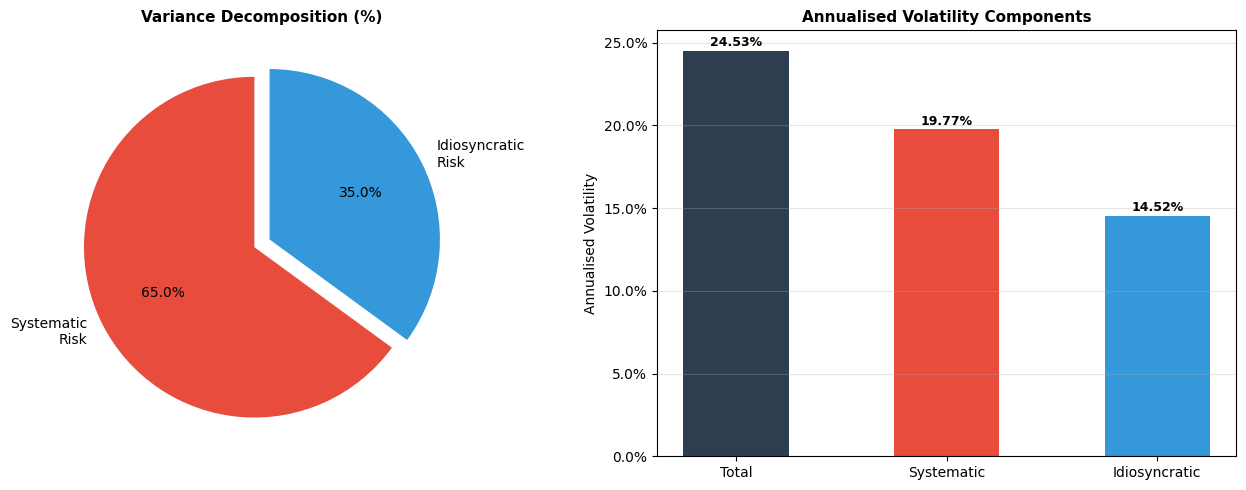

Saved: q2_fig3_variance_decomposition.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels  = ["Systematic\nRisk", "Idiosyncratic\nRisk"]
sizes   = [pct_sys, pct_idio]
cols    = ["#E74C3C", "#3498DB"]
axes[0].pie(sizes, labels=labels, colors=cols, explode=(0.05, 0.05),
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
axes[0].set_title("Variance Decomposition (%)", fontsize=11, fontweight="bold")
vols_bar  = [vol_total, vol_sys, vol_idio]
vlabs_bar = ["Total", "Systematic", "Idiosyncratic"]
bars_v    = axes[1].bar(vlabs_bar, vols_bar, color=["#2C3E50", "#E74C3C", "#3498DB"], width=0.5)
axes[1].set_ylabel("Annualised Volatility")
axes[1].set_title("Annualised Volatility Components", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
for bar, v in zip(bars_v, vols_bar):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{v:.2%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q2_fig3_variance_decomposition.png")

window   = 252
roll_b   = []
roll_d   = []
for i in range(window, len(port_excess)):
    yw = port_excess.values[i-window:i]
    xw = mkt_excess.values[i-window:i]
    slope, *_ = stats.linregress(xw, yw)
    roll_b.append(slope)
    roll_d.append(port_ret.index[i])

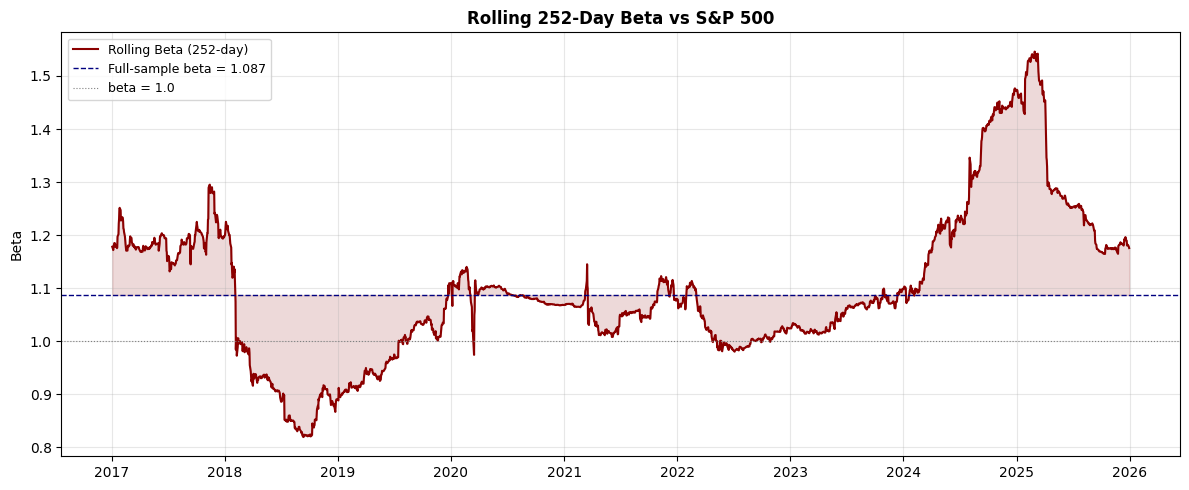

Saved: q2_fig4_rolling_beta.png


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(roll_d, roll_b, color="darkred", linewidth=1.5, label="Rolling Beta (252-day)")
ax.axhline(beta, color="navy",   linewidth=1,  linestyle="--", label=f"Full-sample beta = {beta:.3f}")
ax.axhline(1.0,  color="gray",   linewidth=0.8, linestyle=":", label="beta = 1.0")
ax.fill_between(roll_d, roll_b, beta, alpha=0.15, color="darkred")
ax.set_ylabel("Beta")
ax.set_title("Rolling 252-Day Beta vs S&P 500", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q2_fig4_rolling_beta.png")

i_betas  = []
i_alphas = []
i_mu     = []
for t in TICKERS:
    yi = (eq_ret[t] - RF_D).values
    xi = sm.add_constant(mkt_excess.values)
    mi = sm.OLS(yi, xi).fit()
    i_betas.append(mi.params[1])
    i_alphas.append(mi.params[0] * DAYS)
    i_mu.append(eq_ret[t].mean() * DAYS)

i_betas = np.array(i_betas)
i_mu    = np.array(i_mu)
mkt_rp  = mkt_ret.mean() * DAYS
b_range = np.linspace(0, max(i_betas) * 1.1, 200)
sml     = RF + b_range * (mkt_rp - RF)

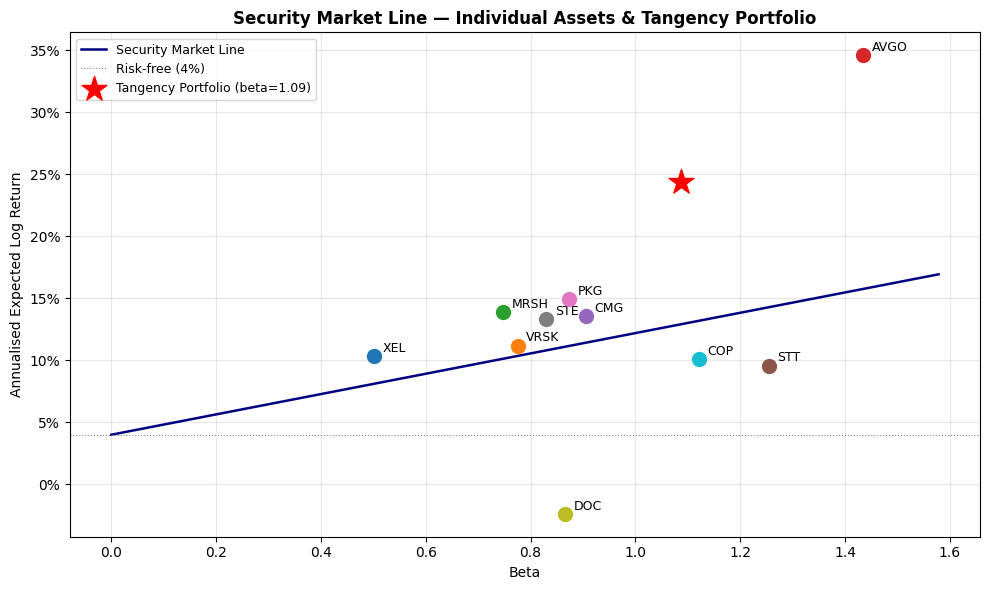

Saved: q2_fig5_sml.png


In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(b_range, sml, color="navy", linewidth=1.8, label="Security Market Line")
ax.axhline(RF, color="gray", linewidth=0.8, linestyle=":", label="Risk-free (4%)")
for j, t in enumerate(TICKERS):
    ax.scatter(i_betas[j], i_mu[j], color=COLORS[j], s=100, zorder=5)
    ax.annotate(t, (i_betas[j], i_mu[j]), textcoords="offset points", xytext=(6, 3), fontsize=9)
mu_port_ann = port_ret.mean() * DAYS
ax.scatter(beta, mu_port_ann, marker="*", s=350, color="red", zorder=6,
           label=f"Tangency Portfolio (beta={beta:.2f})")
ax.set_xlabel("Beta")
ax.set_ylabel("Annualised Expected Log Return")
ax.set_title("Security Market Line — Individual Assets & Tangency Portfolio", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q2_fig5_sml.png")

## Question 3: Value at Risk (VaR)

In [39]:
print("\n" + "=" * 60)
print("QUESTION 3: VALUE AT RISK")
print("=" * 60)

CONF = [0.90, 0.95, 0.99]

def var_hs(r, cl, h=1):
    return -np.percentile(r, (1 - cl) * 100) * np.sqrt(h)

def var_pn(r, cl, h=1):
    mu_r  = np.mean(r)
    sig_r = np.std(r, ddof=1)
    z     = norm.ppf(1 - cl)
    return -(mu_r + z * sig_r) * np.sqrt(h)

def var_cf(r, cl, h=1):
    mu_r  = np.mean(r)
    sig_r = np.std(r, ddof=1)
    sk    = stats.skew(r)
    ku    = stats.kurtosis(r)
    z     = norm.ppf(1 - cl)
    z_cf  = z + (z**2 - 1)*sk/6 + (z**3 - 3*z)*ku/24 - (2*z**3 - 5*z)*sk**2/36
    return -(mu_r + z_cf * sig_r) * np.sqrt(h)

print(f"\nIndividual Asset 1-Day VaR:")
print(f"{'Ticker':<8}", end="")
for cl in CONF:
    print(f"  HS{int(cl*100)}%    PN{int(cl*100)}%    CF{int(cl*100)}%", end="")
print()
print("-" * 80)
for t in TICKERS:
    r = eq_ret[t].values
    print(f"{t:<8}", end="")
    for cl in CONF:
        print(f"  {var_hs(r,cl):.3%}  {var_pn(r,cl):.3%}  {var_cf(r,cl):.3%}", end="")
    print()

p_r = port_ret.values
print(f"\nPortfolio VaR:")
print(f"  {'Method':<22} {'90% 1d':>10} {'95% 1d':>10} {'99% 1d':>10} {'99% 10d':>12}")
print(f"  {'-'*64}")
for name, fn in [("Historical",var_hs), ("Parametric",var_pn), ("Cornish-Fisher",var_cf)]:
    v90 = fn(p_r, 0.90); v95 = fn(p_r, 0.95); v99 = fn(p_r, 0.99); v99_10 = fn(p_r, 0.99, 10)
    print(f"  {name:<22} {v90:>10.4%} {v95:>10.4%} {v99:>10.4%} {v99_10:>12.4%}")

print(f"\nDiversification Benefit in VaR:")
for cl in CONF:
    wsum = sum(w_tan[i] * var_hs(eq_ret[t].values, cl) for i, t in enumerate(TICKERS))
    pvar = var_hs(p_r, cl)
    ben  = wsum - pvar
    pct  = ben / wsum * 100
    print(f"  {int(cl*100)}%:  Undiversified={wsum:.4%}  Portfolio={pvar:.4%}  "
          f"Benefit={ben:.4%} ({pct:.1f}% reduction)")


QUESTION 3: VALUE AT RISK

Individual Asset 1-Day VaR:
Ticker    HS90%    PN90%    CF90%  HS95%    PN95%    CF95%  HS99%    PN99%    CF99%
--------------------------------------------------------------------------------
XEL       1.380%  1.703%  0.572%  2.039%  2.197%  2.110%  3.748%  3.124%  7.718%
VRSK      1.434%  1.824%  0.746%  2.111%  2.354%  2.296%  4.141%  3.348%  7.832%
MRSH      1.268%  1.589%  0.376%  1.831%  2.056%  1.900%  3.748%  2.930%  7.603%
AVGO      2.392%  3.001%  1.050%  3.544%  3.891%  3.464%  6.298%  5.560%  12.346%
CMG       2.157%  2.821%  0.749%  3.184%  3.636%  3.020%  6.351%  5.165%  11.680%
STT       2.115%  2.645%  1.003%  3.207%  3.406%  3.170%  5.995%  4.833%  11.057%
PKG       1.741%  2.168%  1.167%  2.465%  2.799%  2.610%  4.795%  3.983%  7.588%
STE       1.606%  1.959%  1.141%  2.394%  2.530%  2.447%  4.280%  3.600%  6.847%
DOC       2.021%  2.422%  -0.246%  2.762%  3.107%  2.922%  4.917%  4.390%  15.256%
COP       2.409%  3.086%  0.676%  3.526%  3.9

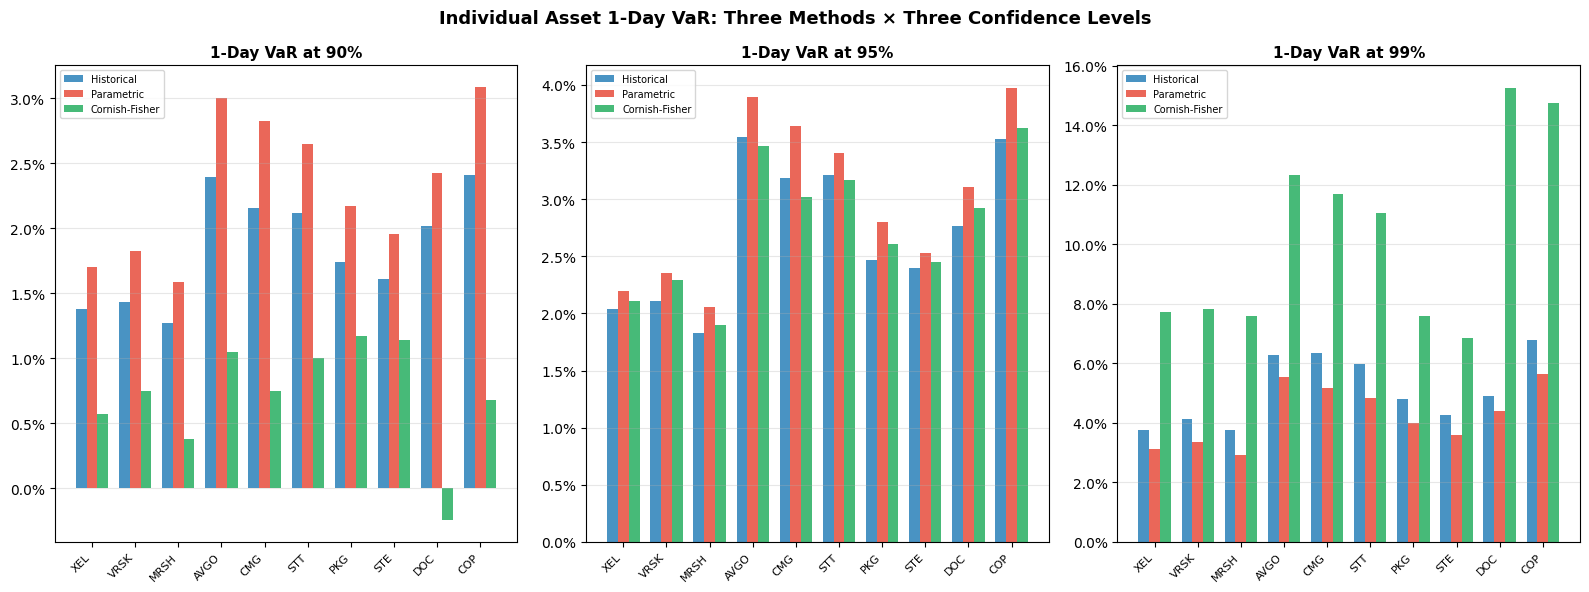


Saved: q3_fig1_individual_var.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, cl, lbl in zip(axes, CONF, ["90%", "95%", "99%"]):
    hs_v = [var_hs(eq_ret[t].values, cl) for t in TICKERS]
    pn_v = [var_pn(eq_ret[t].values, cl) for t in TICKERS]
    cf_v = [var_cf(eq_ret[t].values, cl) for t in TICKERS]
    x = np.arange(N)
    w = 0.25
    ax.bar(x - w, hs_v, width=w, label="Historical",     color="#2980B9", alpha=0.85)
    ax.bar(x,     pn_v, width=w, label="Parametric",     color="#E74C3C", alpha=0.85)
    ax.bar(x + w, cf_v, width=w, label="Cornish-Fisher", color="#27AE60", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"1-Day VaR at {lbl}", fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Individual Asset 1-Day VaR: Three Methods × Three Confidence Levels",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nSaved: q3_fig1_individual_var.png")

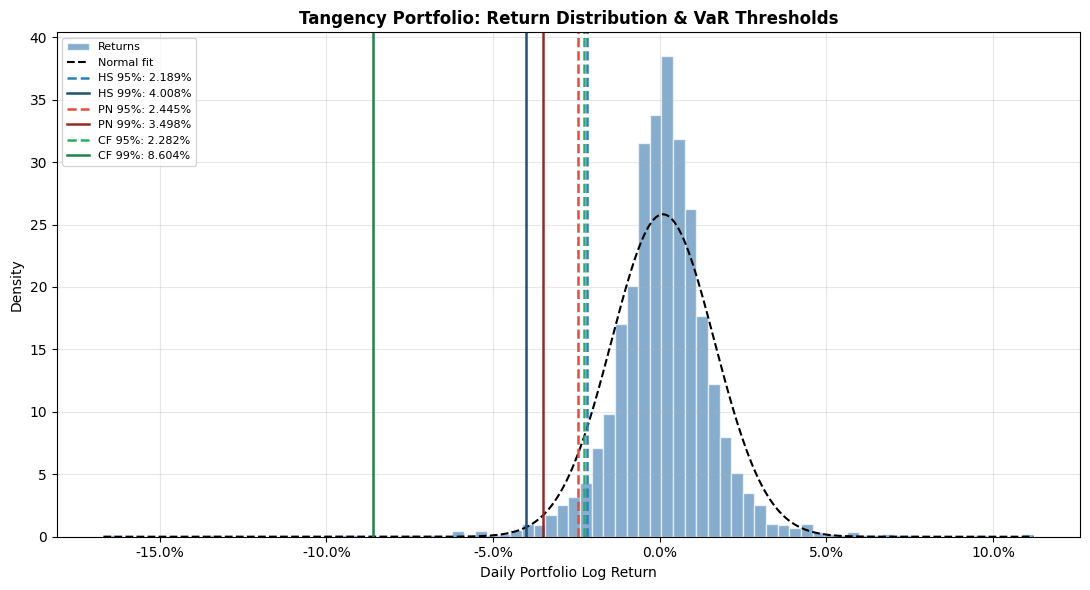

Saved: q3_fig2_portfolio_var.png


In [41]:
fig, ax = plt.subplots(figsize=(11, 6))
mu_p  = np.mean(p_r)
sig_p = np.std(p_r, ddof=1)
ax.hist(p_r, bins=80, color="steelblue", alpha=0.65, edgecolor="white", density=True, label="Returns")
x_fit = np.linspace(p_r.min(), p_r.max(), 400)
ax.plot(x_fit, norm.pdf(x_fit, mu_p, sig_p), "k--", linewidth=1.5, label="Normal fit")
line_info = [
    ("HS 95%",  var_hs(p_r,0.95), "#2980B9", "--"),
    ("HS 99%",  var_hs(p_r,0.99), "#1A5276", "-"),
    ("PN 95%",  var_pn(p_r,0.95), "#E74C3C", "--"),
    ("PN 99%",  var_pn(p_r,0.99), "#922B21", "-"),
    ("CF 95%",  var_cf(p_r,0.95), "#27AE60", "--"),
    ("CF 99%",  var_cf(p_r,0.99), "#1D8348", "-"),
]
for lbl, v, col, ls in line_info:
    ax.axvline(-v, color=col, linewidth=1.8, linestyle=ls, label=f"{lbl}: {v:.3%}")
ax.set_xlabel("Daily Portfolio Log Return")
ax.set_ylabel("Density")
ax.set_title("Tangency Portfolio: Return Distribution & VaR Thresholds", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q3_fig2_portfolio_var.png")

rv95, rv99, rd = [], [], []
for i in range(window, len(port_ret)):
    wr = port_ret.values[i-window:i]
    rv95.append(var_hs(wr, 0.95))
    rv99.append(var_hs(wr, 0.99))
    rd.append(port_ret.index[i])

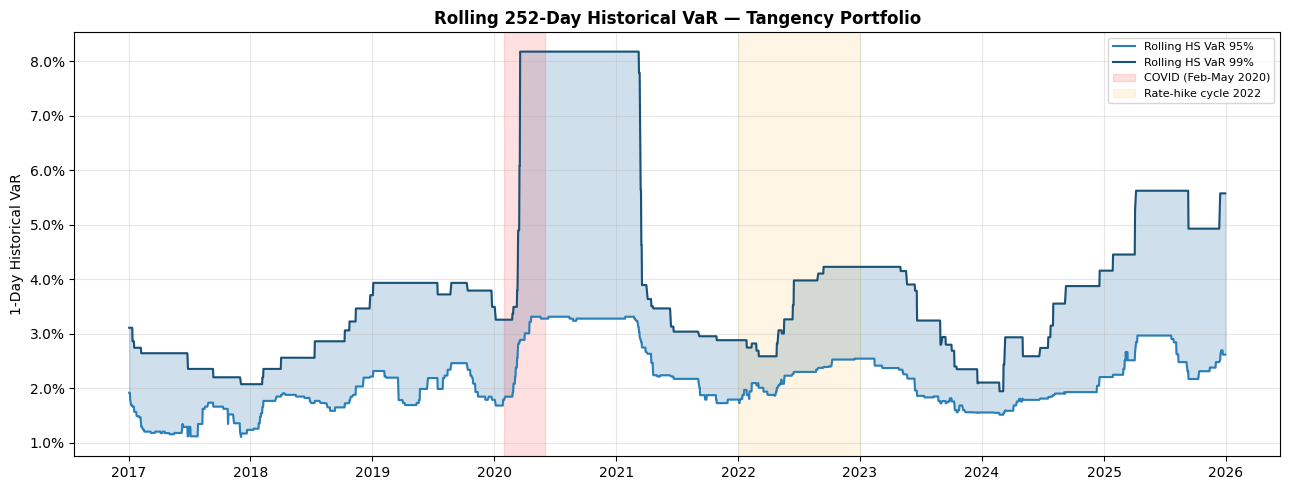

Saved: q3_fig3_rolling_var.png


In [42]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(rd, rv95, rv99, alpha=0.25, color="steelblue")
ax.plot(rd, rv95, color="#2980B9", linewidth=1.5, label="Rolling HS VaR 95%")
ax.plot(rd, rv99, color="#1A5276", linewidth=1.5, label="Rolling HS VaR 99%")
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-01"),
           alpha=0.12, color="red", label="COVID (Feb-May 2020)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
           alpha=0.10, color="orange", label="Rate-hike cycle 2022")
ax.set_ylabel("1-Day Historical VaR")
ax.set_title("Rolling 252-Day Historical VaR — Tangency Portfolio", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Saved: q3_fig3_rolling_var.png")

conf_range = np.linspace(0.80, 0.999, 100)
wsum_arr, port_arr = [], []
for cl in conf_range:
    ws = sum(w_tan[i] * var_hs(eq_ret[t].values, cl) for i, t in enumerate(TICKERS))
    pv = var_hs(p_r, cl)
    wsum_arr.append(ws); port_arr.append(pv)
wsum_arr = np.array(wsum_arr); port_arr = np.array(port_arr)
benefit  = wsum_arr - port_arr

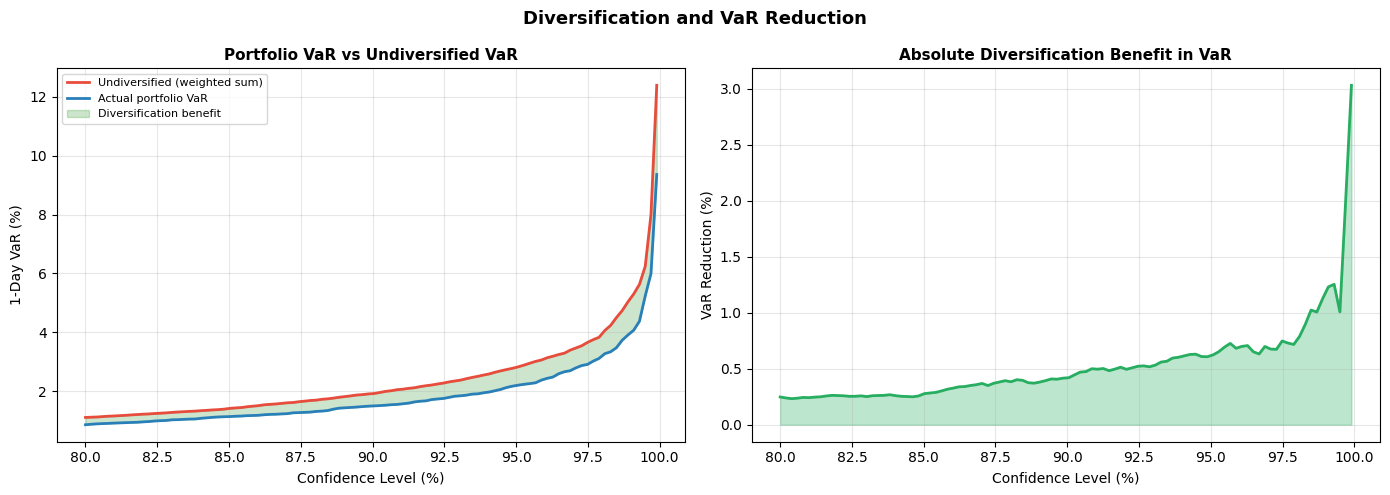

Saved: q3_fig4_diversification_var.png


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(conf_range*100, wsum_arr*100, color="#E74C3C", linewidth=2, label="Undiversified (weighted sum)")
axes[0].plot(conf_range*100, port_arr*100, color="#2980B9", linewidth=2, label="Actual portfolio VaR")
axes[0].fill_between(conf_range*100, wsum_arr*100, port_arr*100, alpha=0.2, color="green", label="Diversification benefit")
axes[0].set_xlabel("Confidence Level (%)"); axes[0].set_ylabel("1-Day VaR (%)")
axes[0].set_title("Portfolio VaR vs Undiversified VaR", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].plot(conf_range*100, benefit*100, color="#27AE60", linewidth=2)
axes[1].fill_between(conf_range*100, 0, benefit*100, alpha=0.3, color="#27AE60")
axes[1].set_xlabel("Confidence Level (%)"); axes[1].set_ylabel("VaR Reduction (%)")
axes[1].set_title("Absolute Diversification Benefit in VaR", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.3)
fig.suptitle("Diversification and VaR Reduction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q3_fig4_diversification_var.png")

all_series = {t: eq_ret[t].values for t in TICKERS}
all_series["Portfolio"] = p_r
all_labels = TICKERS + ["Portfolio"]
conf_lbls  = ["90%", "95%", "99%"]
methods_hm = [("Historical", var_hs), ("Parametric", var_pn), ("Cornish-Fisher", var_cf)]

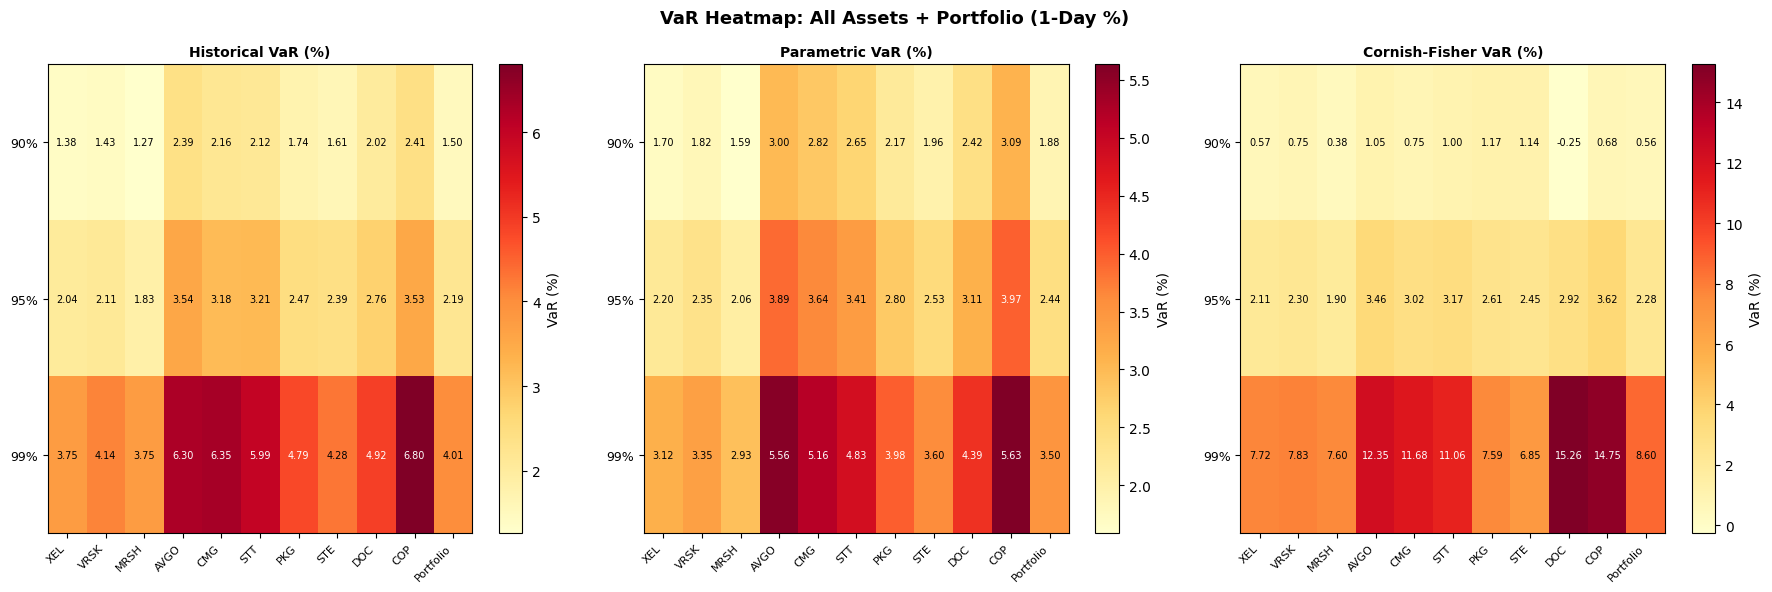

Saved: q3_fig5_var_heatmap.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (mname, mfunc) in zip(axes, methods_hm):
    mat = np.array([[mfunc(all_series[lab], float(cl.strip("%"))/100)*100 for lab in all_labels]
                    for cl in conf_lbls])
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="VaR (%)")
    ax.set_xticks(range(len(all_labels))); ax.set_yticks(range(3))
    ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(conf_lbls, fontsize=9)
    ax.set_title(f"{mname} VaR (%)", fontsize=10, fontweight="bold")
    for i in range(3):
        for j in range(len(all_labels)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="black" if mat[i,j] < mat.max()*0.7 else "white")
fig.suptitle("VaR Heatmap: All Assets + Portfolio (1-Day %)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q3_fig5_var_heatmap.png")

## Question 4: Black-Scholes-Merton Option Pricing (AVGO)

In [45]:
print("\n" + "=" * 60)
print("QUESTION 4: BLACK-SCHOLES OPTIONS (AVGO)")
print("=" * 60)

BSM_T = "AVGO"
avgo  = eq_ret[BSM_T].values
S0    = float(raw[BSM_T].iloc[-1])
K     = S0 * 1.05
sigma = float(np.std(avgo, ddof=1) * np.sqrt(DAYS))

print(f"\n  Current price S0 : ${S0:.4f}")
print(f"  Strike K (+5%)   : ${K:.4f}")
print(f"  Annual vol sigma : {sigma:.4%}")
print(f"  Risk-free rate r : {RF:.2%}")

def d1(S, K, r, sig, T):
    return (np.log(S/K) + (r + 0.5*sig**2)*T) / (sig*np.sqrt(T))

def d2(S, K, r, sig, T):
    return d1(S, K, r, sig, T) - sig*np.sqrt(T)

def bsm_call(S, K, r, sig, T):
    return S*norm.cdf(d1(S,K,r,sig,T)) - K*np.exp(-r*T)*norm.cdf(d2(S,K,r,sig,T))

def bsm_put(S, K, r, sig, T):
    return K*np.exp(-r*T)*norm.cdf(-d2(S,K,r,sig,T)) - S*norm.cdf(-d1(S,K,r,sig,T))

MATS  = [1/12, 3/12, 6/12, 1.0, 2.0]
MLABS = ["1 Month", "3 Months", "6 Months", "1 Year", "2 Years"]

print(f"\n{'Maturity':<12} {'T':>6} {'d1':>10} {'d2':>10} {'N(d1)':>8} {'N(d2)':>8} {'Call':>12} {'Put':>12} {'PCP check':>12}")
print("-" * 100)
for T, lbl in zip(MATS, MLABS):
    _d1  = d1(S0, K, RF, sigma, T)
    _d2  = d2(S0, K, RF, sigma, T)
    _c   = bsm_call(S0, K, RF, sigma, T)
    _p   = bsm_put(S0, K, RF, sigma, T)
    _pcp = _c - _p - (S0 - K*np.exp(-RF*T))
    print(f"{lbl:<12} {T:>6.4f} {_d1:>10.4f} {_d2:>10.4f} {norm.cdf(_d1):>8.4f} "
          f"{norm.cdf(_d2):>8.4f} ${_c:>10.4f} ${_p:>10.4f} {_pcp:>12.2e}")

T1     = 1.0
c1     = bsm_call(S0, K, RF, sigma, T1)
p1     = bsm_put(S0, K, RF, sigma, T1)
d1_1   = d1(S0, K, RF, sigma, T1)
d2_1   = d2(S0, K, RF, sigma, T1)
Nd1    = norm.cdf(d1_1)
Nd2    = norm.cdf(d2_1)

print(f"\nPrimary Result (T = 1 Year):")
print(f"  d1     = {d1_1:.6f}")
print(f"  d2     = {d2_1:.6f}")
print(f"  N(d1)  = {Nd1:.6f}  (call delta / stock-measure ITM prob)")
print(f"  N(d2)  = {Nd2:.6f}  (risk-neutral ITM probability)")
print(f"  N(-d1) = {norm.cdf(-d1_1):.6f}")
print(f"  N(-d2) = {norm.cdf(-d2_1):.6f}")
print(f"  European CALL price = ${c1:.4f}  ({c1/S0*100:.2f}% of S0)")
print(f"  European PUT  price = ${p1:.4f}  ({p1/S0*100:.2f}% of S0)")

delta_call = Nd1
delta_put  = Nd1 - 1
gamma      = norm.pdf(d1_1) / (S0 * sigma * np.sqrt(T1))
vega       = S0 * norm.pdf(d1_1) * np.sqrt(T1) / 100
theta_c    = (-(S0*norm.pdf(d1_1)*sigma)/(2*np.sqrt(T1)) - RF*K*np.exp(-RF*T1)*Nd2) / 365
theta_p    = (-(S0*norm.pdf(d1_1)*sigma)/(2*np.sqrt(T1)) + RF*K*np.exp(-RF*T1)*norm.cdf(-d2_1)) / 365

print(f"\nGreeks (T = 1 Year):")
print(f"  Delta Call = {delta_call:.6f}  |  Delta Put = {delta_put:.6f}")
print(f"  Gamma      = {gamma:.8f}")
print(f"  Vega (per 1% vol) = ${vega:.4f}")
print(f"  Theta Call (per day) = ${theta_c:.4f}")
print(f"  Theta Put  (per day) = ${theta_p:.4f}")

T_rng   = np.linspace(0.01, 3.0, 300)
calls_T = [bsm_call(S0, K, RF, sigma, t) for t in T_rng]
puts_T  = [bsm_put(S0,  K, RF, sigma, t) for t in T_rng]


QUESTION 4: BLACK-SCHOLES OPTIONS (AVGO)

  Current price S0 : $349.1176
  Strike K (+5%)   : $366.5735
  Annual vol sigma : 38.8803%
  Risk-free rate r : 4.00%

Maturity          T         d1         d2    N(d1)    N(d2)         Call          Put    PCP check
----------------------------------------------------------------------------------------------------
1 Month      0.0833    -0.3489    -0.4611   0.3636   0.3224 $    9.1612 $   25.3973    -2.84e-14
3 Months     0.2500    -0.1023    -0.2967   0.4592   0.3833 $   21.2088 $   35.0172     2.84e-14
6 Months     0.5000     0.0327    -0.2422   0.5131   0.4043 $   33.8404 $   44.0376     0.00e+00
1 Year       1.0000     0.1718    -0.2170   0.5682   0.4141 $   52.5225 $   55.6048     2.84e-14
2 Years      2.0000     0.3317    -0.2182   0.6299   0.4137 $   79.9469 $   69.2192     0.00e+00

Primary Result (T = 1 Year):
  d1     = 0.171793
  d2     = -0.217010
  N(d1)  = 0.568200  (call delta / stock-measure ITM prob)
  N(d2)  = 0.414100  (

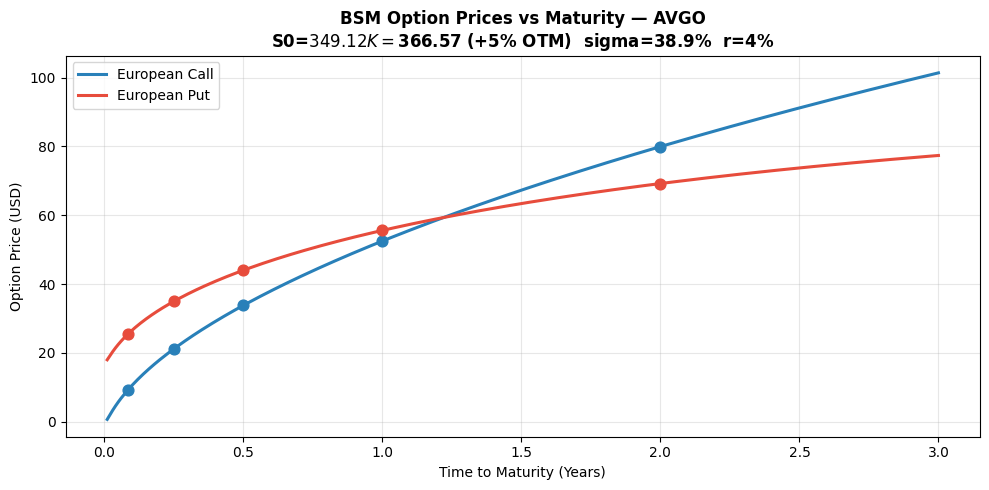


Saved: q4_fig1_price_vs_maturity.png


In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_rng, calls_T, color="#2980B9", linewidth=2.2, label="European Call")
ax.plot(T_rng, puts_T,  color="#E74C3C", linewidth=2.2, label="European Put")
for T, lbl in zip(MATS, MLABS):
    ax.scatter(T, bsm_call(S0,K,RF,sigma,T), color="#2980B9", s=60, zorder=5)
    ax.scatter(T, bsm_put(S0,K,RF,sigma,T),  color="#E74C3C", s=60, zorder=5)
ax.set_xlabel("Time to Maturity (Years)")
ax.set_ylabel("Option Price (USD)")
ax.set_title(f"BSM Option Prices vs Maturity — {BSM_T}\nS0=${S0:.2f}  K=${K:.2f} (+5% OTM)  sigma={sigma:.1%}  r=4%",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nSaved: q4_fig1_price_vs_maturity.png")

S_rng  = np.linspace(S0*0.5, S0*1.7, 400)
c_pay  = np.maximum(S_rng - K, 0)
p_pay  = np.maximum(K - S_rng, 0)
c_prof = c_pay - c1
p_prof = p_pay - p1

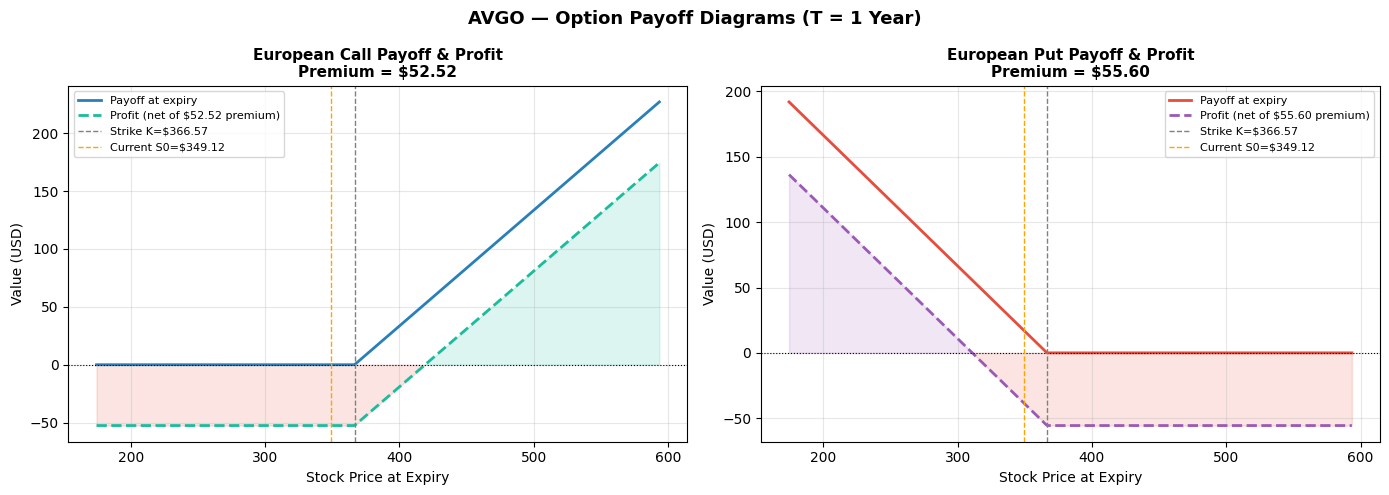

Saved: q4_fig2_payoff_diagrams.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(S_rng, c_pay,  color="#2980B9", linewidth=2, label="Payoff at expiry")
axes[0].plot(S_rng, c_prof, color="#1ABC9C", linewidth=2, linestyle="--", label=f"Profit (net of ${c1:.2f} premium)")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].axvline(K,  color="gray",   linewidth=1, linestyle="--", label=f"Strike K=${K:.2f}")
axes[0].axvline(S0, color="orange", linewidth=1, linestyle="--", label=f"Current S0=${S0:.2f}")
axes[0].fill_between(S_rng, c_prof, 0, where=c_prof>0, alpha=0.15, color="#1ABC9C")
axes[0].fill_between(S_rng, c_prof, 0, where=c_prof<0, alpha=0.15, color="#E74C3C")
axes[0].set_xlabel("Stock Price at Expiry"); axes[0].set_ylabel("Value (USD)")
axes[0].set_title(f"European Call Payoff & Profit\nPremium = ${c1:.2f}", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].plot(S_rng, p_pay,  color="#E74C3C", linewidth=2, label="Payoff at expiry")
axes[1].plot(S_rng, p_prof, color="#9B59B6", linewidth=2, linestyle="--", label=f"Profit (net of ${p1:.2f} premium)")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1].axvline(K,  color="gray",   linewidth=1, linestyle="--", label=f"Strike K=${K:.2f}")
axes[1].axvline(S0, color="orange", linewidth=1, linestyle="--", label=f"Current S0=${S0:.2f}")
axes[1].fill_between(S_rng, p_prof, 0, where=p_prof>0, alpha=0.15, color="#9B59B6")
axes[1].fill_between(S_rng, p_prof, 0, where=p_prof<0, alpha=0.15, color="#E74C3C")
axes[1].set_xlabel("Stock Price at Expiry"); axes[1].set_ylabel("Value (USD)")
axes[1].set_title(f"European Put Payoff & Profit\nPremium = ${p1:.2f}", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
fig.suptitle(f"{BSM_T} — Option Payoff Diagrams (T = 1 Year)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q4_fig2_payoff_diagrams.png")

d1_arr  = [d1(S0, K, RF, sigma, t) for t in T_rng]
d2_arr  = [d2(S0, K, RF, sigma, t) for t in T_rng]
Nd1_arr = [norm.cdf(x) for x in d1_arr]
Nd2_arr = [norm.cdf(x) for x in d2_arr]

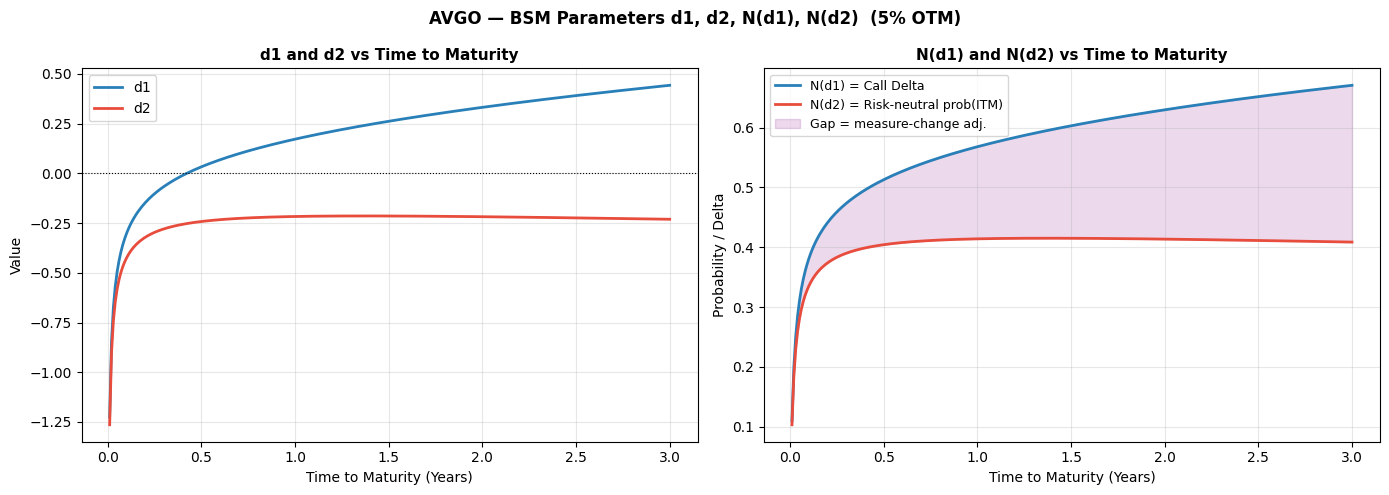

Saved: q4_fig3_d1_d2.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(T_rng, d1_arr, color="#2980B9", linewidth=2, label="d1")
axes[0].plot(T_rng, d2_arr, color="#E74C3C", linewidth=2, label="d2")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_xlabel("Time to Maturity (Years)"); axes[0].set_ylabel("Value")
axes[0].set_title("d1 and d2 vs Time to Maturity", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[1].plot(T_rng, Nd1_arr, color="#2980B9", linewidth=2, label="N(d1) = Call Delta")
axes[1].plot(T_rng, Nd2_arr, color="#E74C3C", linewidth=2, label="N(d2) = Risk-neutral prob(ITM)")
axes[1].fill_between(T_rng, Nd1_arr, Nd2_arr, alpha=0.15, color="purple", label="Gap = measure-change adj.")
axes[1].set_xlabel("Time to Maturity (Years)"); axes[1].set_ylabel("Probability / Delta")
axes[1].set_title("N(d1) and N(d2) vs Time to Maturity", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
fig.suptitle(f"{BSM_T} — BSM Parameters d1, d2, N(d1), N(d2)  (5% OTM)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q4_fig3_d1_d2.png")

S_vals  = np.linspace(S0*0.5, S0*1.5, 400)
cs_S    = [bsm_call(s, K, RF, sigma, 1.0) for s in S_vals]
ps_S    = [bsm_put(s,  K, RF, sigma, 1.0) for s in S_vals]
int_c   = np.maximum(S_vals - K, 0)
int_p   = np.maximum(K - S_vals, 0)

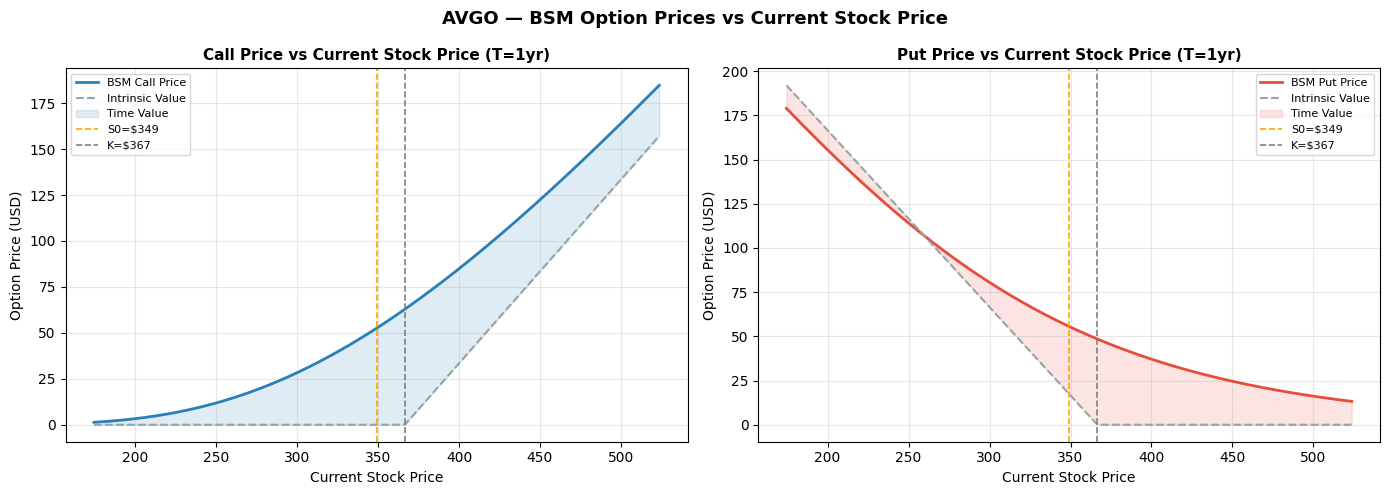

Saved: q4_fig4_price_vs_spot.png


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(S_vals, cs_S,  color="#2980B9", linewidth=2, label="BSM Call Price")
axes[0].plot(S_vals, int_c, color="#95A5A6", linewidth=1.5, linestyle="--", label="Intrinsic Value")
axes[0].fill_between(S_vals, cs_S, int_c, alpha=0.15, color="#2980B9", label="Time Value")
axes[0].axvline(S0, color="orange", linewidth=1.2, linestyle="--", label=f"S0=${S0:.0f}")
axes[0].axvline(K,  color="gray",   linewidth=1.2, linestyle="--", label=f"K=${K:.0f}")
axes[0].set_xlabel("Current Stock Price"); axes[0].set_ylabel("Option Price (USD)")
axes[0].set_title("Call Price vs Current Stock Price (T=1yr)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].plot(S_vals, ps_S,  color="#E74C3C", linewidth=2, label="BSM Put Price")
axes[1].plot(S_vals, int_p, color="#95A5A6", linewidth=1.5, linestyle="--", label="Intrinsic Value")
axes[1].fill_between(S_vals, ps_S, int_p, alpha=0.15, color="#E74C3C", label="Time Value")
axes[1].axvline(S0, color="orange", linewidth=1.2, linestyle="--", label=f"S0=${S0:.0f}")
axes[1].axvline(K,  color="gray",   linewidth=1.2, linestyle="--", label=f"K=${K:.0f}")
axes[1].set_xlabel("Current Stock Price"); axes[1].set_ylabel("Option Price (USD)")
axes[1].set_title("Put Price vs Current Stock Price (T=1yr)", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
fig.suptitle(f"{BSM_T} — BSM Option Prices vs Current Stock Price", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q4_fig4_price_vs_spot.png")

vol_rng  = np.linspace(0.10, 0.80, 200)
calls_v  = [bsm_call(S0, K, RF, v, 1.0) for v in vol_rng]
puts_v   = [bsm_put(S0,  K, RF, v, 1.0) for v in vol_rng]
roll_vol = pd.Series(avgo).rolling(63).std() * np.sqrt(DAYS)

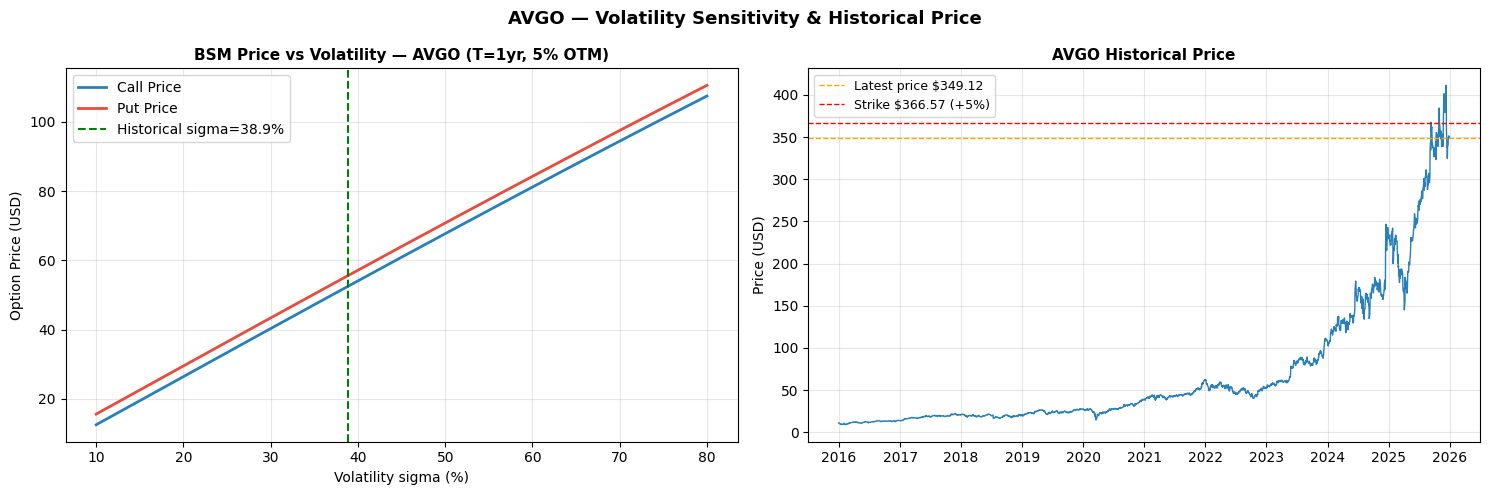

Saved: q4_fig5_vol_and_price.png

ALL DONE — Summary of saved files:
  q1_fig1_cumulative_returns.png
  q1_fig2_portfolio_weights.png
  q1_fig3_efficient_frontier.png
  q1_fig4_correlation_heatmap.png
  q1_fig5_diversification.png
  q2_fig1_capm_scatter.png
  q2_fig2_residuals.png
  q2_fig3_variance_decomposition.png
  q2_fig4_rolling_beta.png
  q2_fig5_sml.png
  q3_fig1_individual_var.png
  q3_fig2_portfolio_var.png
  q3_fig3_rolling_var.png
  q3_fig4_diversification_var.png
  q3_fig5_var_heatmap.png
  q4_fig1_price_vs_maturity.png
  q4_fig2_payoff_diagrams.png
  q4_fig3_d1_d2.png
  q4_fig4_price_vs_spot.png
  q4_fig5_vol_and_price.png

Total: 20 figures


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(vol_rng*100, calls_v, color="#2980B9", linewidth=2, label="Call Price")
axes[0].plot(vol_rng*100, puts_v,  color="#E74C3C", linewidth=2, label="Put Price")
axes[0].axvline(sigma*100, color="green", linewidth=1.5, linestyle="--", label=f"Historical sigma={sigma:.1%}")
axes[0].set_xlabel("Volatility sigma (%)"); axes[0].set_ylabel("Option Price (USD)")
axes[0].set_title(f"BSM Price vs Volatility — {BSM_T} (T=1yr, 5% OTM)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[1].plot(raw[BSM_T].index, raw[BSM_T].values, color="#2980B9", linewidth=1)
axes[1].axhline(S0, color="orange", linewidth=1, linestyle="--", label=f"Latest price ${S0:.2f}")
axes[1].axhline(K,  color="red",    linewidth=1, linestyle="--", label=f"Strike ${K:.2f} (+5%)")
axes[1].set_ylabel("Price (USD)"); axes[1].set_title(f"{BSM_T} Historical Price", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
fig.suptitle(f"{BSM_T} — Volatility Sensitivity & Historical Price", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Saved: q4_fig5_vol_and_price.png")

print("\n" + "=" * 60)
print("ALL DONE — Summary of saved files:")
print("=" * 60)
files = [
    "q1_fig1_cumulative_returns.png",
    "q1_fig2_portfolio_weights.png",
    "q1_fig3_efficient_frontier.png",
    "q1_fig4_correlation_heatmap.png",
    "q1_fig5_diversification.png",
    "q2_fig1_capm_scatter.png",
    "q2_fig2_residuals.png",
    "q2_fig3_variance_decomposition.png",
    "q2_fig4_rolling_beta.png",
    "q2_fig5_sml.png",
    "q3_fig1_individual_var.png",
    "q3_fig2_portfolio_var.png",
    "q3_fig3_rolling_var.png",
    "q3_fig4_diversification_var.png",
    "q3_fig5_var_heatmap.png",
    "q4_fig1_price_vs_maturity.png",
    "q4_fig2_payoff_diagrams.png",
    "q4_fig3_d1_d2.png",
    "q4_fig4_price_vs_spot.png",
    "q4_fig5_vol_and_price.png",
]
for f in files:
    print(f"  {f}")
print(f"\nTotal: {len(files)} figures")